<a href="https://colab.research.google.com/github/fadeeva/normal_projects/blob/master/Loan%20Prediction%20Problem/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

path = kagglehub.dataset_download('altruistdelhite04/loan-prediction-problem-dataset')

print('Path to dataset files:', path)

100%|██████████| 12.6k/12.6k [00:00<00:00, 18.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altruistdelhite04/loan-prediction-problem-dataset/versions/1


In [ ]:
! ls {path}

test_Y3wMUE5_7gLdaTN.csv  train_u6lujuX_CVtuZ9i.csv


In [3]:
df = pd.read_csv(f'{path}/train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
missing_df = pd.DataFrame({
    'col': df.columns,
    'type': df.dtypes.values,
    'missing vals': df.isnull().sum().values,
    '% missing vals': (df.isnull().sum() / len(df)*100).values
})

missing_df

,col,type,missing vals,% missing vals
0,Loan_ID,object,0,0.000000
1,Gender,object,13,2.117264
2,Married,object,3,0.488599
3,Dependents,object,15,2.442997
4,Education,object,0,0.000000
5,Self_Employed,object,32,5.211726
6,ApplicantIncome,int64,0,0.000000
7,CoapplicantIncome,float64,0,0.000000
8,LoanAmount,float64,22,3.583062
9,Loan_Amount_Term,float64,14,2.280130


In [18]:
missing_df['missing vals'].sum()

np.int64(149)

In [23]:
missing_dict = {}

for col in df.columns:
    missing_by_target = df[df[col].isnull()].groupby('Loan_Status').size()
    missing_dict[col] = missing_by_target

result_df = pd.DataFrame(missing_dict).fillna(0).astype(int)
result_df.T

Loan_Status,N,Y
Loan_ID,0,0
Gender,5,8
Married,0,3
Dependents,6,9
Education,0,0
Self_Employed,9,23
ApplicantIncome,0,0
CoapplicantIncome,0,0
LoanAmount,11,11
Loan_Amount_Term,6,8


In [24]:
result_df.T[['N', 'Y']].sum()

,0
Loan_Status,
N,50
Y,99


In [6]:
df.value_counts('Gender')

,count
Gender,
Male,489
Female,112


In [13]:
df.groupby(['Gender', 'Loan_Status']).count()['Loan_ID']

Gender  Loan_Status
Female  N               37
        Y               75
Male    N              150
        Y              339
Name: Loan_ID, dtype: int64

In [11]:
df.groupby(['Gender', 'Loan_Status', 'Married', 'Education']).count()['Loan_ID']

Gender  Loan_Status  Married  Education   
Female  N            No       Graduate         24
                              Not Graduate      5
                     Yes      Graduate          7
                              Not Graduate      1
        Y            No       Graduate         42
                              Not Graduate      9
                     Yes      Graduate         18
                              Not Graduate      5
Male    N            No       Graduate         37
                              Not Graduate     12
                     Yes      Graduate         68
                              Not Graduate     33
        Y            No       Graduate         62
                              Not Graduate     19
                     Yes      Graduate        207
                              Not Graduate     49
Name: Loan_ID, dtype: int64

(array([513.,  77.,  14.,   1.,   4.,   2.,   1.,   1.,   0.,   1.]),
 array([ 1442. ,  9397.8, 17353.6, 25309.4, 33265.2, 41221. , 49176.8,
        57132.6, 65088.4, 73044.2, 81000. ]),
 <BarContainer object of 10 artists>)

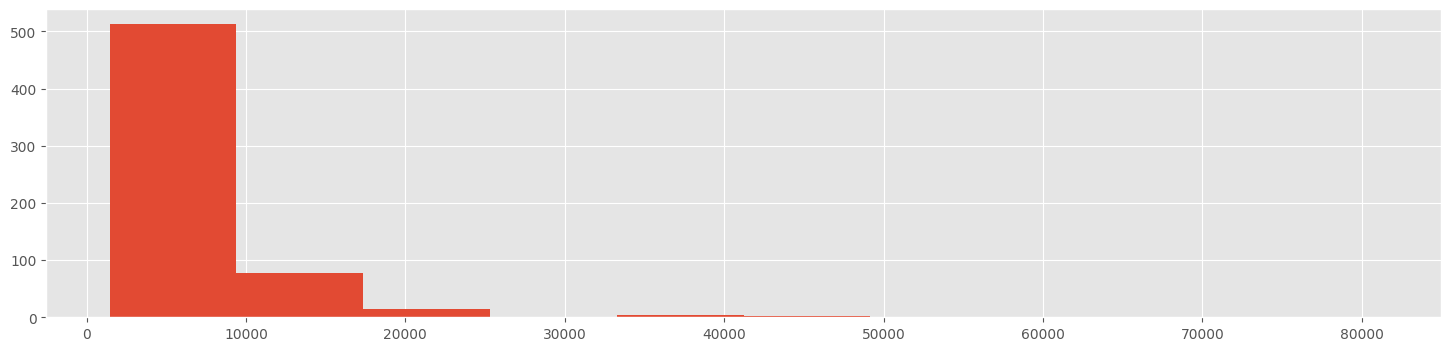

In [30]:
plt.figure(figsize=(18, 4))
plt.hist(df['ApplicantIncome']+df['CoapplicantIncome'])

In [28]:
df['ApplicantIncome'].describe()

,ApplicantIncome
count,614.000000
mean,5403.459283
std,6109.041673
min,150.000000
25%,2877.500000
50%,3812.500000
75%,5795.000000
max,81000.000000
